# 4: Dask — Scalable raster arrays

**Goal:** See how Dask keeps rasters **chunked** and **lazy**, then runs work in parallel on `.compute()`.


Download `data/` if you do not have it yet: [Google Drive zip](https://drive.google.com/file/d/10vINdbyeQtFCgrd7NhVawkC0v-wEGHwb/view?usp=sharing). Extract it next to this notebook.



## The idea

A NumPy array is one block in memory. A **Dask array** is the same shape, split into chunks. Arithmetic builds a **task graph**; nothing runs until you ask.

| Idea | Meaning |
|------|---------|
| Chunked | The raster is a grid of blocks (each block is a task) |
| Lazy | `prec.mean(...)` records work; it does not read the file yet |
| Parallel | `.compute()` runs chunk tasks together (threads by default) |
| Reduce first | `.mean()`, `.sum()`, a slice — shrink before you compute |

These three files are a good pair: ERA5-Land is **many days, few pixels**; the DEM is **one band, many pixels**. Similar file size, different chunking story.


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import rioxarray
import xarray as xr


## Open with `chunks=` (Dask-backed)

`open_rasterio` without chunks loads what you ask into NumPy. With `chunks=`, the result is a Dask array: header now, pixels later.

- Climate: chunk **time** (`band`) so a month can be one task, and keep spatial chunks modest.
- DEM: chunk **space** (1024 x 1024). A 10k x 9k elevation grid should not enter RAM as one block.


In [2]:
DATA = Path("data")
prec_path = DATA / "prec_daily_2024_ERA5LAND_native.tif"
temp_path = DATA / "temp_daily_2024_ERA5LAND_native.tif"
dem_path = DATA / "copernicus_dem_30m.tif"

prec = rioxarray.open_rasterio(prec_path, chunks={"band": 30, "x": 200, "y": 200})
temp = rioxarray.open_rasterio(temp_path, chunks={"band": 30, "x": 200, "y": 200})
dem = rioxarray.open_rasterio(dem_path, chunks={"x": 1024, "y": 1024}).squeeze(
    "band", drop=True
)

print("prec", prec.shape, type(prec.data), "chunks", prec.data.npartitions)
print("temp", temp.shape, type(temp.data), "chunks", temp.data.npartitions)
print("dem ", dem.shape, type(dem.data), "chunks", dem.data.npartitions)
print(
    "Logical MB  prec/temp/dem:",
    round(prec.nbytes / 1e6, 1),
    round(temp.nbytes / 1e6, 1),
    round(dem.nbytes / 1e6, 1),
    "- not loaded yet",
)


prec (366, 313, 431) <class 'dask.array.core.Array'> chunks 78
temp (366, 313, 431) <class 'dask.array.core.Array'> chunks 78
dem  (10173, 9406) <class 'dask.array.core.Array'> chunks 100
Logical MB  prec/temp/dem: 395.0 395.0 382.7 - not loaded yet


## Inspect one Dask array

`prec` is `(band, y, x)` = 366 days x a small ERA5 window. Dask stores that as many blocks. The object still looks like xarray.


In [3]:
print("Array type:", type(prec.data))
print("Dims / shape:", prec.dims, prec.shape)
print("Chunk layout:", prec.chunks)
print("Tasks so far (open only):", len(prec.data.dask))
prec


Array type: <class 'dask.array.core.Array'>
Dims / shape: ('band', 'y', 'x') (366, 313, 431)
Chunk layout: ((30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 6), (200, 113), (200, 200, 31))
Tasks so far (open only): 79


<xarray.DataArray (band: 366, y: 313, x: 431)> Size: 395MB
dask.array<open_rasterio-69512bac8d64f99f4a1fb15984151cef<this-array>, shape=(366, 313, 431), dtype=float64, chunksize=(30, 200, 200), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 3kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365 366
  * x            (x) float64 3kB 3.364 3.373 3.381 3.39 ... 7.208 7.217 7.226
  * y            (y) float64 3kB 53.56 53.55 53.54 53.53 ... 50.77 50.76 50.75
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('20240101_2024-01-01', '20240102_2024-01-02', '20240103_...

## Lazy arithmetic

Kelvin to Celsius and a wet-day mask look like NumPy. They only add nodes to the graph — still no full read.


In [4]:
temp_c = temp - 273.15
wet = prec > 0.001  # ERA5 precip is metres; 1 mm = 0.001 m

print("temp_c still Dask?", type(temp_c.data))
print("Tasks after two expressions:", len(temp_c.data.dask), len(wet.data.dask))
print(temp_c.data)


temp_c still Dask? <class 'dask.array.core.Array'>
Tasks after two expressions: 157 157
dask.array<sub, shape=(366, 313, 431), dtype=float64, chunksize=(30, 200, 200), chunktype=numpy.ndarray>


## `.compute()` runs the graph

A **spatial mean** collapses `y` and `x` to one value per day. Dask reads chunk by chunk and returns a small 1-D series — not a 366 x 313 x 431 cube in RAM.


In [5]:
prec_ts = prec.mean(dim=("y", "x"))
temp_ts = temp_c.mean(dim=("y", "x"))
print("Time series still lazy:", type(prec_ts.data), prec_ts.shape)

t0 = time.perf_counter()
prec_ts_c = prec_ts.compute()
temp_ts_c = temp_ts.compute()
print(f"First compute: {time.perf_counter() - t0:.2f} s")
print("Mean daily precip (m):", float(prec_ts_c.mean()))
print("Mean daily temp (C):", float(temp_ts_c.mean()))


Time series still lazy: <class 'dask.array.core.Array'> (366,)
First compute: 19.52 s
Mean daily precip (m): 2.9244249411545837
Mean daily temp (C): -261.35814404559557


## `.persist()` — compute once, keep chunks

`.compute()` gave us the series and dropped intermediate climate chunks. `.persist()` runs the graph and **keeps the cube in memory** so the next reductions do not re-read the GeoTIFF.


In [6]:
prec_mem = prec.persist()
temp_c_mem = temp_c.persist()

t0 = time.perf_counter()
wet_frac = (prec_mem > 0.001).mean(dim=("y", "x")).compute()
print("Wet-day fraction (spatial mean), first 5 days:", wet_frac.values[:5].round(3))
print(f"Reduction after persist: {time.perf_counter() - t0:.2f} s")


Wet-day fraction (spatial mean), first 5 days: [0.414 0.414 0.414 0.414 0.414]
Reduction after persist: 0.14 s


## The DEM: many more spatial chunks

About the same size on disk as one climate stack, but roughly 10,000 x 9,000 pixels. Without chunks this is one huge array. With 1024 x 1024 it is about 100 blocks. Mean elevation is a single number — Dask streams the tiles.


In [7]:
print("DEM chunks:", dem.chunks)
print("DEM partitions:", dem.data.npartitions)

t0 = time.perf_counter()
dem_mean = float(dem.mean().compute())
print("Mean elevation (m):", round(dem_mean, 1))
print(f"DEM reduction: {time.perf_counter() - t0:.2f} s")


DEM chunks: ((1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 957), (1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 1024, 190))
DEM partitions: 100
Mean elevation (m): 4.4
DEM reduction: 0.82 s


## Rechunk: more tasks vs more RAM

Smaller chunks mean more parallelism and more scheduler overhead. Larger chunks mean fewer tasks and more memory per task. For these GeoTIFFs, 512-1024 on the DEM and about 30-day slabs on climate are a reasonable start.


In [8]:
print("DEM partitions now:", dem.data.npartitions)
dem_fine = dem.chunk({"x": 512, "y": 512})
print("DEM partitions after 512:", dem_fine.data.npartitions)
print("Same mean:", round(float(dem_fine.mean().compute()), 1))


DEM partitions now: 100
DEM partitions after 512: 380
Same mean: 4.4


## Plot (implicit compute)

matplotlib needs real numbers. We compute **one day** of precipitation and a **small DEM window** — not the whole stacks.


/var/folders/xk/h38d4p4d1n399s98y8lhlw580000gn/T/ipykernel_24039/714238454.py:10: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


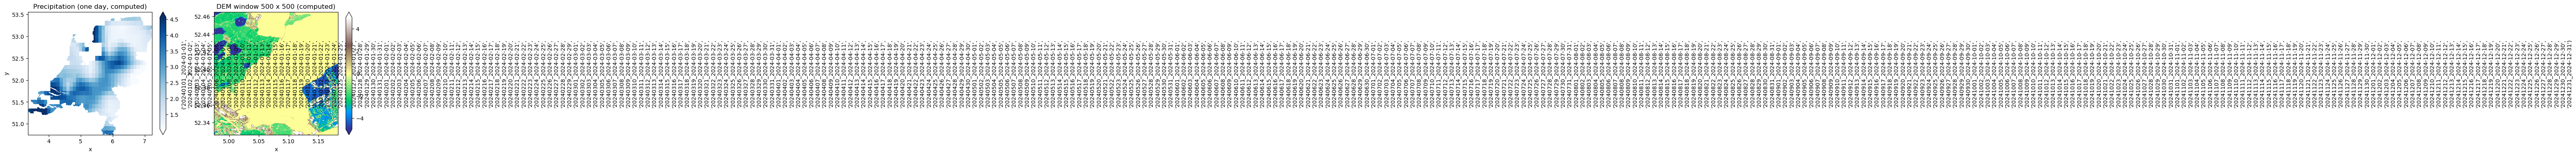

In [9]:
prec_day = prec_mem.isel(band=151)  # ~1 June if band 1 is 1 Jan
dem_win = dem.isel(y=slice(4000, 4500), x=slice(4000, 4500))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
prec_day.plot(ax=axes[0], robust=True, cmap="Blues")
axes[0].set_title("Precipitation (one day, computed)")

dem_win.plot(ax=axes[1], robust=True, cmap="terrain")
axes[1].set_title("DEM window 500 x 500 (computed)")
plt.tight_layout()
plt.show()


## Daily mean time series

The series we already computed — one number per day over the ERA5 window.


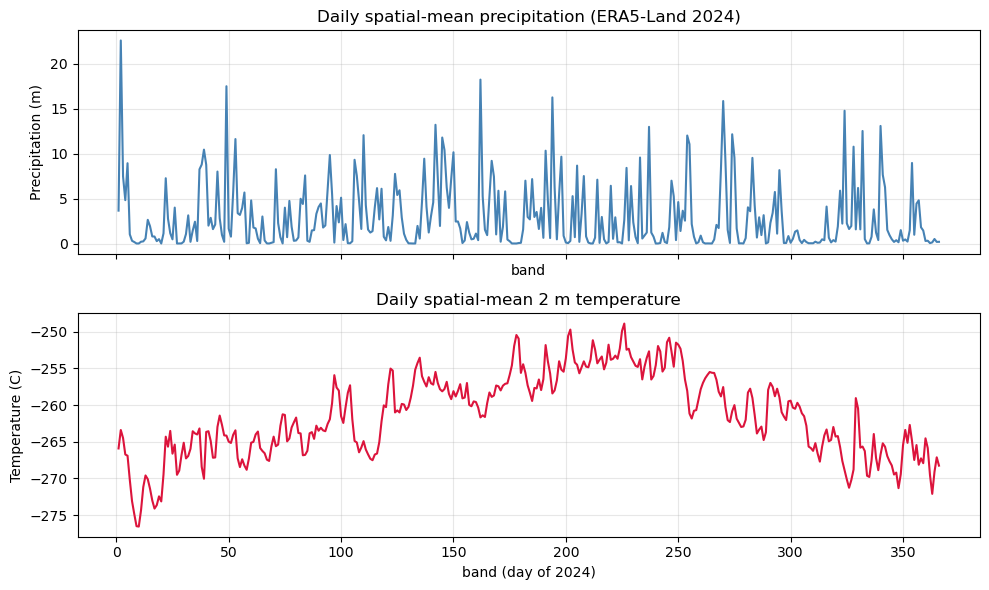

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
prec_ts_c.plot(ax=axes[0], color="steelblue")
axes[0].set_ylabel("Precipitation (m)")
axes[0].set_title("Daily spatial-mean precipitation (ERA5-Land 2024)")
axes[0].grid(True, alpha=0.3)

temp_ts_c.plot(ax=axes[1], color="crimson")
axes[1].set_ylabel("Temperature (C)")
axes[1].set_title("Daily spatial-mean 2 m temperature")
axes[1].set_xlabel("band (day of 2024)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## When does compute run?

| Trigger | What happens |
|---------|----------------|
| `.compute()` | Run the graph; return NumPy / in-memory xarray |
| `.persist()` | Run the graph; keep chunks in memory for reuse |
| `.plot()` | Implicit compute of that slice |
| `+`, `/`, `.mean()`, `> 0.001`, `.isel()` | Still lazy |

